在此文件中调查对于给定储层（已知其理想状态下的指标指标和任务表现）在噪声环境下的表现

In [6]:
import os
import torch 
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import pickle

from pathlib import Path

CANDIDATES = [
    
    Path(r"C:\Users\tom\Desktop\Repository"),
    Path(r"C:\Users\Chen\Desktop\Repository"),
]
searchpaths = [p for p in CANDIDATES if p.exists()]

#tuple of repos
repos = ('machine_learning_library',)

import sys
import os
# In Jupyter notebooks, __file__ is not defined. Use the current working directory instead.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import repo_tools
repo_tools.repos_path_finder(searchpaths, repos)
from spnc import spnc_anisotropy
import spnc_ml as ml
from deterministic_mask import fixed_seed_mask, max_sequences_mask

from single_node_res import single_node_reservoir
import ridge_regression as RR
from linear_layer import *
from mask import binary_mask
from utility import *
from NARMA10 import NARMA10
from datasets.load_TI46_digits import *
import datasets.load_TI46 as TI46
from sklearn.metrics import classification_report
from formal_Parameter_Dynamics_Preformance import *

In [2]:
# 检查当前代码是否可以实现噪音添加
from numpy._core.numeric import True_


noise_free = ReservoirParams(
    h=0.4,
    beta_prime=50.0,
    Nvirt=200,
    m0=0.008,
    verbose_repr=False,
    params={
        'theta': 0.156493838858319,
        'gamma': 0.0460842584494091,
        'delay_feedback': 0,
        'Nvirt': 200,
        'voltage_noise': False,
        'seed_voltage_noise': 1234,
        'delta_V': 0.1,
        'johnson_noise': False,
        'seed_johnson_noise': 1234,
        'mean_johnson_noise': 0.0000,
        'std_johnson_noise': 0.00001,
        'thermal_noise': False,
        'seed_thermal_noise': 1234,
        'lambda_ou': 1.0,
        'sigma_ou': 0.1,
    }
)

noise = ReservoirParams(
    h=0.4,
    beta_prime=50.0,
    Nvirt=200,
    m0=0.008,
    verbose_repr=False,
    params={
        'theta': 0.156493838858319,
        'gamma': 0.0460842584494091,
        'delay_feedback': 0,
        'Nvirt': 200,
        'voltage_noise': False,
        'seed_voltage_noise': 1234,
        'delta_V': 0.1,
        'johnson_noise': True,
        'seed_johnson_noise': 1234,
        'mean_johnson_noise': 0.0000,
        'std_johnson_noise': 0.0015998587196060573,
        'thermal_noise': False,
        'seed_thermal_noise': 1234,
        'lambda_ou': 1.0,
        'sigma_ou': 0.1,
    }
)

# 创建一个spnc对象
spn_noisefree = spnc_anisotropy(noise_free.h, noise_free.theta_H, noise_free.k_s_0, noise_free.phi, noise_free.beta_prime, restart=True)

spn_noise = spnc_anisotropy(noise.h, noise.theta_H, noise.k_s_0, noise.phi, noise.beta_prime, restart=True)

# 选择合适的transform
if noise_free.params.get('johnson_noise', False) or noise_free.params.get('thermal_noise', False):
    transform = spn_noisefree.gen_signal_slow_delayed_feedback_noise
    print("Using transform: gen_signal_slow_delayed_feedback_noise")
else:
    transform = spn_noisefree.gen_signal_slow_delayed_feedback
    print("Using transform: gen_signal_slow_delayed_feedback")

if noise.params.get('johnson_noise', False) or noise.params.get('thermal_noise', False):
    transform_noise = spn_noise.gen_signal_slow_delayed_feedback_noise
    print("Using transform: gen_signal_slow_delayed_feedback_noise")
else:
    transform_noise = spn_noise.gen_signal_slow_delayed_feedback
    print("Using transform: gen_signal_slow_delayed_feedback")





Using transform: gen_signal_slow_delayed_feedback
Using transform: gen_signal_slow_delayed_feedback_noise


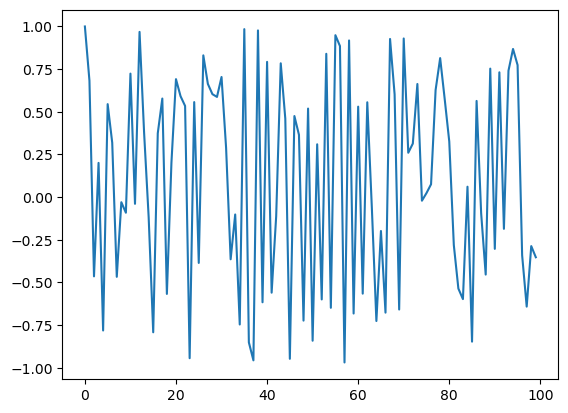

In [145]:
# 生成输入信号
input = 2 * np.random.rand(100) - 1
plt.plot(input)
plt.show()

#将input reshape
input = input.reshape(-1, 1)

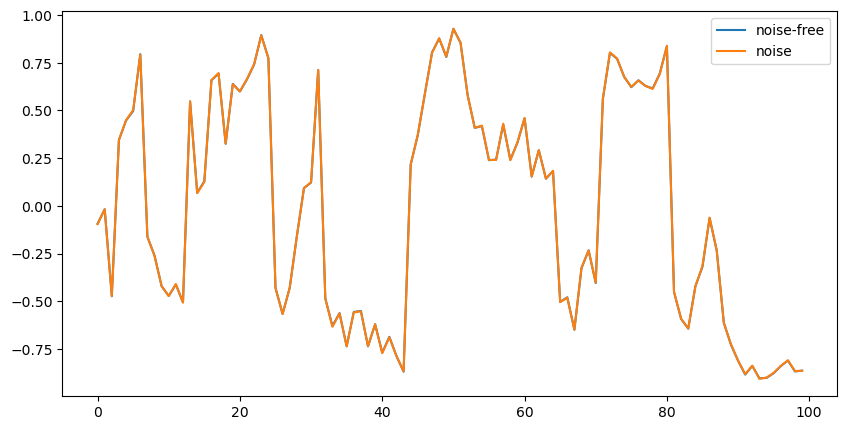

In [146]:
output_noisefree = spn_noisefree.gen_signal_slow_delayed_feedback(input, noise_free.params)
# 要注意beta_prime的值是否会触发‘e_b_min * beta_prime <= 3’
output_noise = spn_noise.gen_signal_slow_delayed_feedback_noise(input, noise.params,spn_noise.beta_prime)

plt.figure(figsize=(10, 5))
plt.plot(output_noisefree,label='noise-free')
plt.plot(output_noise,label='noise')
plt.legend()
plt.show()


以上的结果已经证明了我们成功地添加了噪音

接下来，让我们看看添加噪音之后是否对MC产生影响

In [34]:
MC_noisefree = evaluate_MC(noise_free, signal_len=550)
MC_noise = evaluate_MC(noise, signal_len=550)

print('MC_noisefree:',MC_noisefree)
print('MC_noise:',MC_noise)

res_m0: 0.008, res_gamma: 0.0460842584494091, MC: 6.107485564223881
res_m0: 0.008, res_gamma: 0.0460842584494091, MC: 0.17402658089515713
MC_noisefree: {'MC': np.float64(6.107485564223881)}
MC_noise: {'MC': np.float64(0.17402658089515713)}


结果似乎证明了噪声的存在（取决于强度）对储层的记忆能力产生影响

接下来让我们看看KRandGR

In [35]:
result_noisefree = evaluate_KRandGR(noise_free, Nreadouts=50, Nwash=10)
result_noise = evaluate_KRandGR(noise, Nreadouts=50, Nwash=10)

print('noise_free result:',result_noisefree)
print('noise result:',result_noise)



noise_free result: {'KR': 17, 'GR': 4, 'CQ': 13}
noise result: {'KR': 9, 'GR': 4, 'CQ': 5}


根据以上的结果，特定的johnson噪音的加入会降低MC，但会轻微抬升KR。

接下来让我们看看johnson噪音强度与计算指标的相关性

In [7]:
import pandas as pd
magnitudes = np.concatenate(([0], np.logspace(-5, -1, 50)))
records = []

for magnitude in magnitudes:
    noise.params['std_johnson_noise'] = magnitude
    result_MC = evaluate_MC(noise, signal_len=550)
    result_KRandGR = evaluate_KRandGR(noise, Nreadouts=50, Nwash=10, threshold=0.001)

    records.append({
        'magnitude': magnitude,
        'MC': result_MC['MC'],
        'KR': result_KRandGR['KR'],
        'GR': result_KRandGR['GR'],
        'CQ': result_KRandGR['CQ']
    })

df = pd.DataFrame(records)

# 将df保存为csv文件
df.to_csv('johnson_noise_bestMC_th0001.csv', index=False)







KeyboardInterrupt: 

In [9]:
# 从'johnson_noise_bestMC_th0001.csv中读取df
with open('johnson_noise_bestMC_th0001.csv', 'rb') as f:
    df = pd.read_csv(f)


In [10]:
print(df['magnitude'][28])

0.001599858719606


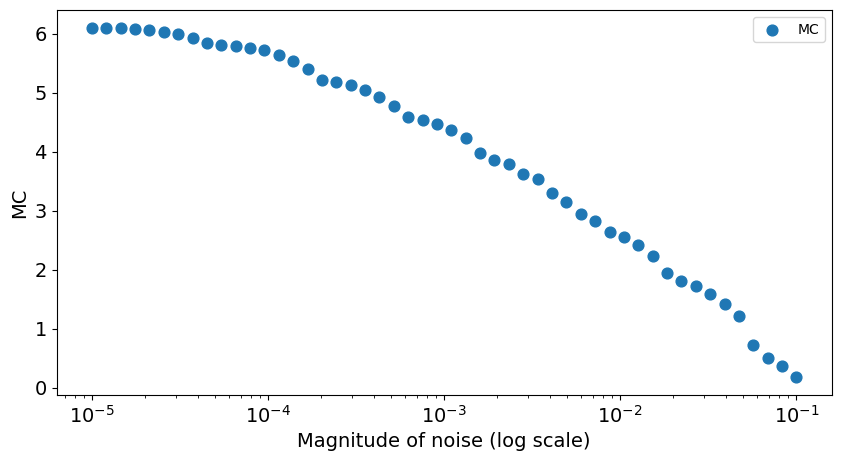

In [13]:
# 画出MC和KR的图像
plt.figure(figsize=(10, 5))
plt.scatter(df['magnitude'], df['MC'], label='MC',s =60)
plt.xscale('log')
plt.xlabel('Magnitude of noise (log scale)',fontsize=14)
plt.ylabel('MC',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.show()


28


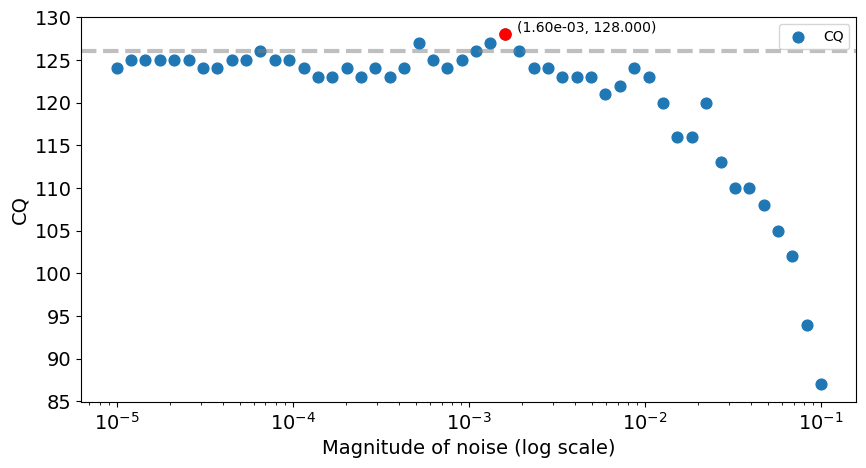

In [16]:
# 画出MC和KR的图像
plt.figure(figsize=(10, 5))
plt.scatter(df['magnitude'], df['CQ'], label='CQ',s =60)
plt.xscale('log')
plt.xlabel('Magnitude of noise (log scale)',fontsize=14)
plt.ylabel('CQ',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# 细化y轴刻度尺，步长为2,保持原有范围
plt.yticks(np.arange(80, 131, 5))

# 添加一个基准线、
plt.axhline(y=126, color='gray', linestyle='--', linewidth=3, alpha=0.5)

# 找到最大值的索引和坐标
max_idx = df['CQ'].idxmax()
max_magnitude = df.loc[max_idx, 'magnitude']
max_cq = df.loc[max_idx, 'CQ']
print(max_idx)

# 在图上标注最大值点
plt.plot(max_magnitude, max_cq, 'ro', markersize=8)
plt.annotate(f'({max_magnitude:.2e}, {max_cq:.3f})', 
             xy=(max_magnitude, max_cq), 
             xytext=(9, 2), 
             textcoords='offset points',
)

plt.legend()
plt.show()

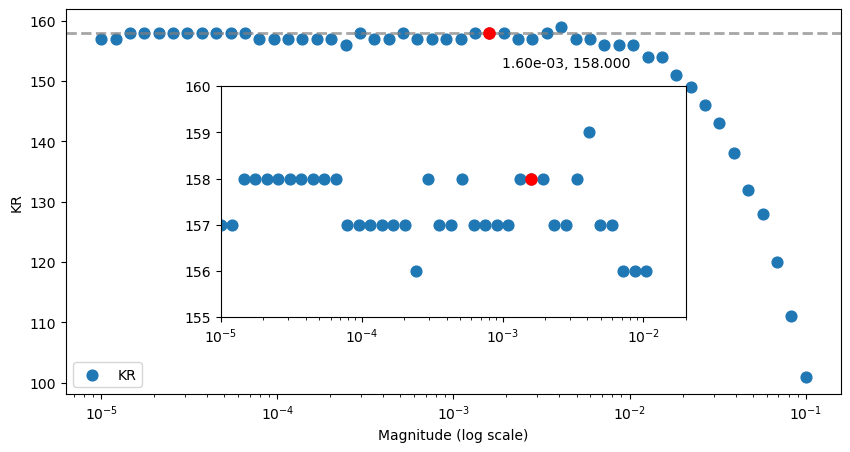

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

# 主图：全局 KR vs Magnitude
ax.scatter(df['magnitude'], df['KR'], label='KR',s =60)
ax.set_xscale('log')
ax.axhline(y=158, color='gray', linestyle='--', linewidth=2, alpha=0.7)

# 找最大值
max_idx = df['KR'].idxmax()
max_magnitude = df.loc[max_idx, 'magnitude']
max_kr = df.loc[max_idx, 'KR']

# 标注最大值
# 找到idx=28的点
target_idx = 28
target_kr = df.loc[target_idx, 'KR']
target_magnitude = df.loc[target_idx, 'magnitude']
plt.plot(target_magnitude, target_kr, 'ro', markersize=8)
plt.annotate(f'{target_magnitude:.2e}, {target_kr:.3f}', 
             xy=(target_magnitude, target_kr), 
             xytext=(9, -25), 
             textcoords='offset points',
)
ax.set_xlabel("Magnitude (log scale)")
ax.set_ylabel("KR")
ax.legend()
# ax.grid(alpha=0.3)

# ── inset 小窗口 ──
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 创建 inset：大小为主图的 40% × 40%，位置在右上角
axins = inset_axes(ax, width="60%", height="60%", loc="center")

# 在 inset 里画相同的数据
axins.scatter(df['magnitude'], df['KR'],s =60)
axins.set_xscale('log')
#也标注出idx=28的点
axins.plot(target_magnitude, target_kr, 'ro', markersize=8)

# 设置放大的 y 区间 150–160
axins.set_ylim(155, 160)
axins.set_xlim(0.00001, 0.02)

plt.show()


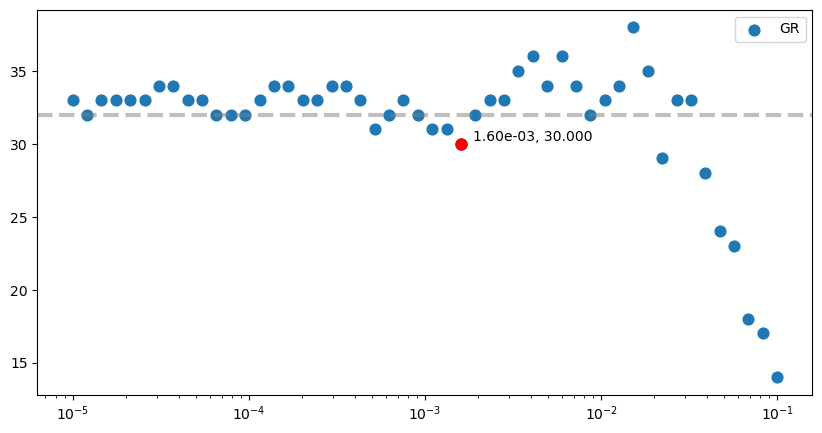

In [ ]:
# 画出MC和KR的图像
plt.figure(figsize=(10, 5))
plt.scatter(df['magnitude'], df['GR'], label='GR',s =60)
plt.xscale('log')


plt.axhline(y=32, color='gray', linestyle='--', linewidth=3, alpha=0.5)

# 找到索引为28的点，标注出来
target_idx = 28
target_gr = df.loc[target_idx, 'GR']
target_magnitude = df.loc[target_idx, 'magnitude']
plt.plot(target_magnitude, target_gr, 'ro', markersize=8)
plt.annotate(f'{target_magnitude:.2e}, {target_gr:.3f}', 
             xy=(target_magnitude, target_gr), 
             xytext=(9, 2), 
             textcoords='offset points',
)


plt.legend()
plt.show()

接下来让我们看看任务表现

In [3]:
# 评估NARMA10
narma10_noisefree = evaluate_NARMA10(noise_free)

narma10_noise = evaluate_NARMA10(noise)

Using transform: gen_signal_slow_delayed_feedback
Seed Training: 1234
len(x_train): 2000
error with zero =  0.004421615048610153
0.0057536146031720225 0.6854114245694962
Using transform: gen_signal_slow_delayed_feedback_noise
Seed Training: 1234
len(x_train): 2000
error with zero =  0.006976074372457464
0.006497679040417227 0.7283834721809167


In [4]:
# 评估TI46
acc_noisefree = evaluate_Ti46(noise_free,nvirt_ti46=150)

acc_noise = evaluate_Ti46(noise,nvirt_ti46=150)

Using transform: gen_signal_slow_delayed_feedback
Samples for training:  500
first 5 samples for training:  [array([ 0, -1, -1, ..., -1,  0,  0], shape=(14848,), dtype=int16)
 array([-1,  0,  0, ..., -2, -2, -2], shape=(13056,), dtype=int16)
 array([-1, -1, -1, ...,  2,  1,  1], shape=(13056,), dtype=int16)
 array([ 0, -1,  0, ..., -1, -1, -1], shape=(16640,), dtype=int16)
 array([-1,  0, -1, ...,  0, -1,  0], shape=(12800,), dtype=int16)]
Samples for test:  795
Using MFCC preprocessing
Nin = 13 , Nout =  10 , Nvirt =  150
Deterministic mask will be used
the shape of the mask is:  (150, 13)
Seed Training: 1234
len(x_train): 7999
error with zero =  0.06363892924411793
Optimal regression parameter =  0.004991593906910133
Train report
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        40
           1      0.909     1.000     0.952        40
           2      1.000     1.000     1.000        40
           3      1.000     1.000     1.0